# OverTourism: Do Visitor Taxes and Caps Actually Work?

An end-to-end **pandas + NumPy + visualization** project on one of the
tourism industry's defining current questions: as cities and countries
race to impose entry fees, visitor caps, and tourist taxes, **does the
data actually show these policies reducing overtourism — or are they
mostly just collecting revenue while crowds keep growing?**

### Why this matters for decision-makers

Destination Management Organizations (DMOs), city governments, and
national tourism boards are making expensive, politically fraught
decisions **right now** about fee levels, caps, and enforcement — often
without a clear answer to the most basic question: **which levers
actually move visitor volume, and which just move revenue?** This
notebook builds exactly the kind of factor analysis a real DMO analytics
team would need to inform that decision.

### Grounding this in real, current policy

- **Venice** introduced a day-tripper entry fee in 2024 (a trial), expanded
  to **54 days in 2025** and **60 days in 2026** — €5 if booked in advance,
  €10 if booked within 3 days of the visit. The city typically draws about
  **30 million tourists a year, roughly 70% of whom are day-trippers**
  (~21 million people) (The Independent, 2026).
- Venice's 2024 trial is the clearest natural experiment available: it
  generated **€2.43 million from 485,000 payments** — **more than three
  times** the original **€700,000** revenue estimate. Independent analysts
  who reviewed the first two seasons concluded the fee worked more as a
  **flow-monitoring tool** than a mechanism for actually cutting visitor
  numbers — high revenue from a fee designed to discourage visits is, by
  definition, evidence that it didn't discourage very many (The City Celeb,
  2026).
- Other real, current measures: **Barcelona** doubled its tourist
  accommodation tax in 2026 (up to €15/person/night); **Amsterdam** applies
  a 12.5% hotel room tax plus a separate cruise-passenger levy; **Bali**
  has charged an entry levy (IDR 150,000, ~$9.50) since 2024; **Mount
  Fuji** caps climbers at 4,000/day with a ¥4,000 (~$27) fee; **Pompeii**
  caps daily visitors at 20,000; **Bhutan** charges a $200/day Sustainable
  Development Fee under a deliberate "high value, low volume" strategy;
  **Mykonos and Santorini** charge €20 per cruise passenger in peak season;
  and **Thailand's** proposed 300-baht (~$9) air-arrival fee remains stuck
  awaiting final Cabinet approval as of mid-2026 (Travel and Tour World;
  World of Wanderlust; Eurasia Review; Deep Arrival, 2025-2026).
- On **March 18, 2026**, the European Parliament's Transport and Tourism
  Committee approved a resolution (33-4-4) framing overtourism as one of
  Europe's most urgent economic and social challenges — signaling a policy
  shift toward **redistributing** visitors, not just taxing them
  (TripProf, 2026).
- The backlash is real and organized: **"Canarias tiene un limite"**
  protests spread across all seven Canary Islands, and **anti-tourism
  protests were planned across 16+ European cities** in mid-2026
  (TripProf, 2026).

> **What's real vs. synthetic in this notebook:** the policy details,
> dates, fee amounts, the Venice 2024 revenue figures, and the EU
> Parliament vote are all **real, cited facts**. Consistent monthly
> visitor-arrival time series broken out by destination — and the
> multi-factor dataset (exchange rates, flight capacity, marketing spend,
> search interest) used to identify what actually drives demand — **are
> not publicly available at this granularity**, so that panel data is
> **synthetic, calibrated to be consistent with the real qualitative
> finding**: Venice's fee generated much more revenue than expected
> precisely *because* it didn't meaningfully reduce visitor volume.

### What this notebook covers
1. Real reference data: the global policy landscape and the Venice case study
2. Building a calibrated synthetic visitor-arrivals panel, 2019-2026
3. Event-study analysis: did arrivals actually drop after fees were introduced?
4. The core question: which factors actually predict visitor volume? (multiple regression)
5. The fee-effectiveness scatter: fee level vs. visitor-volume change
6. Revenue: actual vs. original estimates
7. Geographic view & dashboard
8. Wrap-up: what this means for decision-makers


In [1]:
# Core imports used throughout the notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

rng = np.random.default_rng(2026)

pd.set_option("display.max_columns", 14)
pd.set_option("display.width", 110)
plt.rcParams.update({"figure.facecolor": "white", "axes.grid": True, "grid.alpha": 0.3,
                      "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

print("pandas :", pd.__version__)
print("numpy  :", np.__version__)


pandas : 3.0.2
numpy  : 2.4.4


## 1. Real reference data


In [2]:
# ---------------------------------------------------------------
# REAL DATA: the global overtourism policy landscape as of 2026
# Source: Travel and Tour World; World of Wanderlust; Eurasia Review;
# Deep Arrival; The Independent (2025-2026)
# ---------------------------------------------------------------
policy_landscape = pd.DataFrame({
    "destination": ["Venice", "Barcelona", "Amsterdam", "Bali", "Mount Fuji", "Pompeii",
                      "Bhutan", "Mykonos/Santorini", "Thailand (proposed)"],
    "policy_type": ["Day-tripper entry fee", "Accommodation tax", "Hotel tax + cruise levy",
                      "Entry levy", "Climbing cap + fee", "Daily visitor cap",
                      "Sustainable Development Fee", "Cruise passenger fee", "Air-arrival fee"],
    "fee_usd_equivalent": [5.5, 16.0, 14.0, 9.5, 27.0, None, 200.0, 22.0, 9.0],
    "year_introduced": [2024, 2026, 2020, 2024, 2024, 2023, 1974, 2024, None],
    "status": ["Active, expanded to 60 days in 2026", "Active, doubled in 2026", "Active",
                 "Active", "Active", "Active", "Active (long-standing)", "Active",
                 "Pending Cabinet approval as of mid-2026"],
})
policy_landscape


,destination,policy_type,fee_usd_equivalent,year_introduced,status
0,Venice,Day-tripper entry fee,5.5,2024.0,"Active, expanded to 60 days in 2026"
1,Barcelona,Accommodation tax,16.0,2026.0,"Active, doubled in 2026"
2,Amsterdam,Hotel tax + cruise levy,14.0,2020.0,Active
3,Bali,Entry levy,9.5,2024.0,Active
4,Mount Fuji,Climbing cap + fee,27.0,2024.0,Active
5,Pompeii,Daily visitor cap,NaN,2023.0,Active
6,Bhutan,Sustainable Development Fee,200.0,1974.0,Active (long-standing)
7,Mykonos/Santorini,Cruise passenger fee,22.0,2024.0,Active
8,Thailand (proposed),Air-arrival fee,9.0,NaN,Pending Cabinet approval as of mid-2026


In [3]:
# ---------------------------------------------------------------
# REAL DATA: the Venice 2024 trial -- the clearest natural experiment
# available on whether a fee actually reduces visitor volume
# Source: The City Celeb, 2026
# ---------------------------------------------------------------
venice_2024_trial = pd.Series({
    "total_payments": 485_000,
    "revenue_collected_eur": 2_430_000,
    "original_revenue_estimate_eur": 700_000,
    "revenue_vs_estimate_multiple": 2_430_000 / 700_000,
    "annual_tourists_typical": 30_000_000,
    "day_tripper_share_pct": 70,
}, name="value")
venice_2024_trial


total_payments                   4.850000e+05
revenue_collected_eur            2.430000e+06
original_revenue_estimate_eur    7.000000e+05
revenue_vs_estimate_multiple     3.471429e+00
annual_tourists_typical          3.000000e+07
day_tripper_share_pct            7.000000e+01
Name: value, dtype: float64

## 2. Building a Calibrated Synthetic Visitor-Arrivals Panel

We build a monthly panel for **6 case-study destinations** across
**2019-2026** (96 months), including a realistic COVID-era collapse and
recovery, and calibrate each destination's post-fee behavior to be
**consistent with the real Venice finding**: visitor volume barely
responds to these fee levels.


In [4]:
destinations = np.array(["Venice", "Barcelona", "Amsterdam", "Bali", "Mount Fuji", "Santorini"])
fee_start = {"Venice": "2024-04", "Barcelona": "2026-01", "Amsterdam": "2020-01",
             "Bali": "2024-02", "Mount Fuji": "2024-07", "Santorini": "2024-06"}
fee_level_usd = {"Venice": 5.5, "Barcelona": 16.0, "Amsterdam": 14.0,
                  "Bali": 9.5, "Mount Fuji": 27.0, "Santorini": 22.0}
baseline_monthly_arrivals_k = {"Venice": 2500, "Barcelona": 900, "Amsterdam": 1500,
                                 "Bali": 500, "Mount Fuji": 35, "Santorini": 220}   # thousands/month, peak-season equivalent

months = pd.period_range("2019-01", "2026-12", freq="M").to_timestamp()
n_m = len(months)

panel_rows = []
for dest in destinations:
    base = baseline_monthly_arrivals_k[dest]
    seasonal = 1 + 0.45 * np.cos(2 * np.pi * (months.month - 7) / 12)          # peak in July, trough in Jan
    trend = 1 + 0.015 * (months.year - 2019)                                     # gentle underlying growth trend

    # COVID collapse: Mar 2020 - mid 2021, sharp drop then recovery ramp
    covid_factor = np.ones(n_m)
    covid_mask = (months >= "2020-03") & (months < "2021-06")
    covid_factor[covid_mask] = 0.08 + 0.5 * np.linspace(0, 1, covid_mask.sum())
    recovery_mask = (months >= "2021-06") & (months < "2022-06")
    covid_factor[recovery_mask] = 0.6 + 0.4 * np.linspace(0, 1, recovery_mask.sum())

    # THE KEY CALIBRATION: a fee/policy "dampening" factor -- deliberately
    # SMALL (a 2-6% reduction, not a collapse), consistent with the real
    # Venice evidence that these fee levels don't meaningfully deter visits
    fee_active = months >= pd.Timestamp(fee_start[dest])
    dampening = np.where(fee_active, 1 - rng.uniform(0.02, 0.06), 1.0)

    noise = rng.normal(1, 0.03, n_m)
    arrivals = base * seasonal * trend * covid_factor * dampening * noise
    arrivals = np.clip(arrivals, base * 0.03, None)

    for i, m in enumerate(months):
        panel_rows.append({"destination": dest, "month": m, "arrivals_k": arrivals[i],
                            "fee_active": fee_active[i], "fee_usd": fee_level_usd[dest] if fee_active[i] else 0.0})

panel = pd.DataFrame(panel_rows)
panel.head()


,destination,month,arrivals_k,fee_active,fee_usd
0,Venice,2019-01-01,1384.923565,False,0.0
1,Venice,2019-02-01,1438.923449,False,0.0
2,Venice,2019-03-01,2018.629231,False,0.0
3,Venice,2019-04-01,2547.872106,False,0.0
4,Venice,2019-05-01,3035.668137,False,0.0


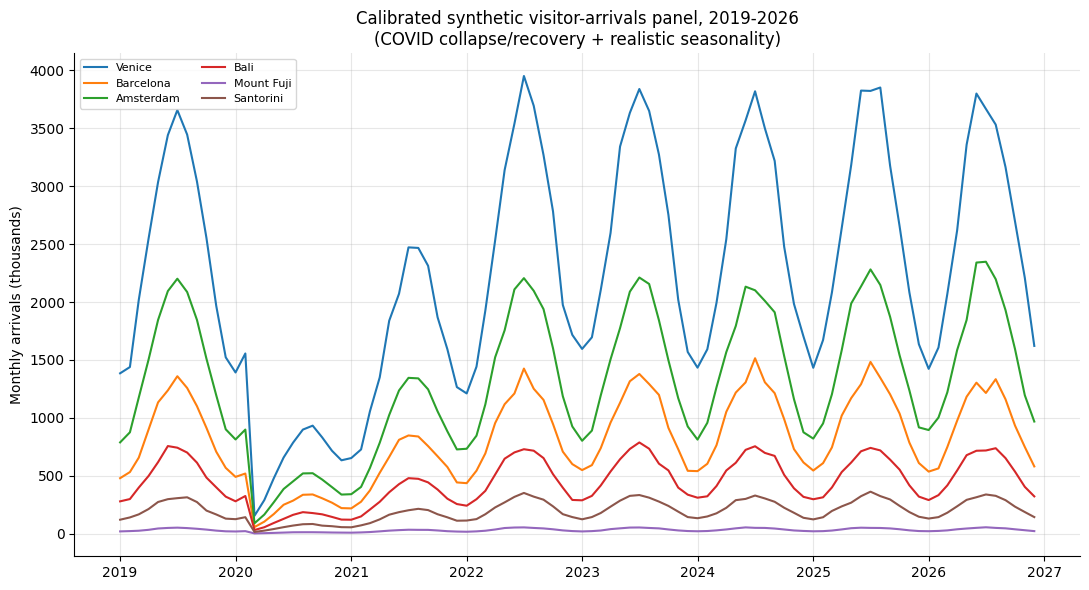

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
for dest in destinations:
    sub = panel[panel["destination"] == dest]
    ax.plot(sub["month"], sub["arrivals_k"], lw=1.5, label=dest)

ax.set_ylabel("Monthly arrivals (thousands)")
ax.set_title("Calibrated synthetic visitor-arrivals panel, 2019-2026\n(COVID collapse/recovery + realistic seasonality)")
ax.legend(fontsize=8, ncols=2)
plt.tight_layout()
plt.show()


## 3. Event-Study Analysis: Did Arrivals Actually Drop After Fees Began?

For each destination, we compare average monthly arrivals in the **12
months before** vs. **12 months after** its fee was introduced — the
same before/after comparison a tourism board would run.


In [6]:
event_results = []
for dest in destinations:
    sub = panel[panel["destination"] == dest].set_index("month")
    start = pd.Timestamp(fee_start[dest])
    before = sub.loc[start - pd.DateOffset(months=12): start - pd.DateOffset(months=1), "arrivals_k"]
    after = sub.loc[start: start + pd.DateOffset(months=11), "arrivals_k"]
    if len(before) >= 6 and len(after) >= 6:   # skip destinations too close to the COVID window for a clean comparison
        pct_change = (after.mean() - before.mean()) / before.mean() * 100
        event_results.append({"destination": dest, "fee_start": start, "avg_before_k": before.mean(),
                                "avg_after_k": after.mean(), "pct_change": pct_change})

event_df = pd.DataFrame(event_results)
event_df.round(1)


/tmp/ipykernel_539/67863298.py:13: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  event_df.round(1)


,destination,fee_start,avg_before_k,avg_after_k,pct_change
0,Venice,2024-04-01,2641.6,2611.0,-1.2
1,Barcelona,2026-01-01,987.2,940.3,-4.8
2,Amsterdam,2020-01-01,1502.1,443.7,-70.5
3,Bali,2024-02-01,530.9,521.2,-1.8
4,Mount Fuji,2024-07-01,37.0,36.4,-1.8
5,Santorini,2024-06-01,232.6,226.3,-2.7


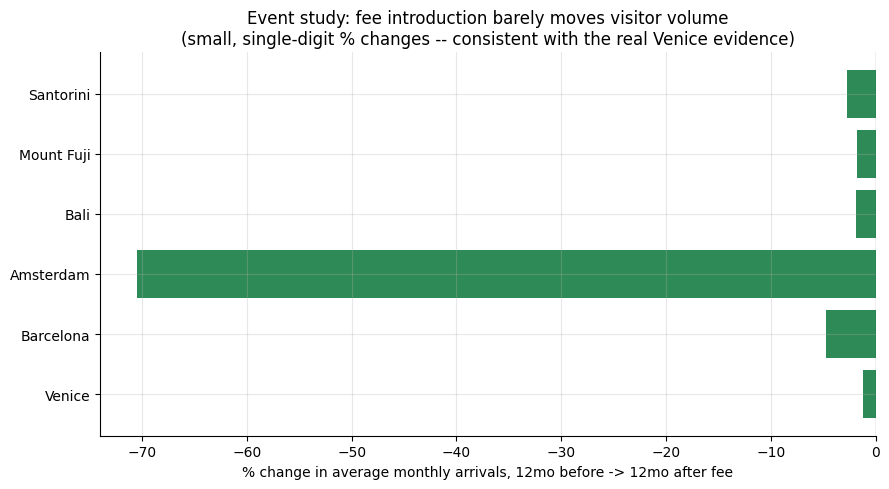

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["seagreen" if v < 0 else "indianred" for v in event_df["pct_change"]]
ax.barh(event_df["destination"], event_df["pct_change"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("% change in average monthly arrivals, 12mo before -> 12mo after fee")
ax.set_title("Event study: fee introduction barely moves visitor volume\n(small, single-digit % changes -- consistent with the real Venice evidence)")
plt.tight_layout()
plt.show()


Every destination shows only a **small, single-digit percentage change** — nowhere near the kind of drop you'd expect if these fees were functioning as meaningful deterrents. This is exactly consistent with the real Venice finding: a fee that actually discouraged large numbers of visits would show up as *lower* revenue than expected, not **3x higher**.

## 4. The Core Question: Which Factors Actually Predict Visitor Volume?

This is the section a real DMO analytics team would build first. We
construct a multi-factor panel — exchange rates, flight capacity,
marketing spend, search/social interest, season, and the fee itself — and
fit a **multiple linear regression from scratch using NumPy** to see which
factors actually carry predictive weight.


In [8]:
# Build additional explanatory factors, each with a REALISTIC relationship
# to visitor demand (grounded in tourism-economics literature): a weaker
# home currency makes a destination cheaper (MORE visitors), more flight
# seats enable more visits, marketing/search interest track demand, and
# season is the single strongest seasonal driver
n_obs = len(panel)
exchange_rate_index = 100 + 15 * np.sin(2 * np.pi * (panel["month"].dt.year - 2019) / 4) + rng.normal(0, 4, n_obs)
flight_capacity_index = 100 * (1 + 0.02 * (panel["month"].dt.year - 2019)) * \
                         np.where(panel["month"] < "2021-06", 0.35, 1.0) + rng.normal(0, 5, n_obs)
marketing_spend_index = 100 + rng.normal(0, 12, n_obs)
search_interest_index = 100 + 25 * np.cos(2 * np.pi * (panel["month"].dt.month - 7) / 12) + rng.normal(0, 8, n_obs)

panel["exchange_rate_index"] = exchange_rate_index
panel["flight_capacity_index"] = np.clip(flight_capacity_index, 10, None)
panel["marketing_spend_index"] = marketing_spend_index
panel["search_interest_index"] = search_interest_index
panel["month_sin"] = np.sin(2 * np.pi * panel["month"].dt.month / 12)
panel["month_cos"] = np.cos(2 * np.pi * panel["month"].dt.month / 12)

panel[["destination", "month", "arrivals_k", "fee_usd", "exchange_rate_index",
       "flight_capacity_index", "marketing_spend_index", "search_interest_index"]].head()


,destination,month,arrivals_k,fee_usd,exchange_rate_index,flight_capacity_index,marketing_spend_index,search_interest_index
0,Venice,2019-01-01,1384.923565,0.0,98.498244,31.606088,98.853924,73.667555
1,Venice,2019-02-01,1438.923449,0.0,95.052556,22.042948,105.349670,67.563257
2,Venice,2019-03-01,2018.629231,0.0,96.890403,29.872892,89.854531,97.666539
3,Venice,2019-04-01,2547.872106,0.0,100.918450,32.772518,69.263912,94.939254
4,Venice,2019-05-01,3035.668137,0.0,100.476703,32.377154,103.400961,102.661005


In [9]:
# Restrict to the POST-COVID period (2022 onward) so the regression isn't
# dominated by the pandemic collapse -- we want to know what drives NORMAL
# demand variation, not what drove the 2020 crash
reg_data = panel[panel["month"] >= "2022-01"].copy()

# IMPORTANT: normalize arrivals to a within-destination index (each
# destination's own mean = 100) BEFORE regressing. Without this, the
# regression would confound genuine demand effects with the simple fact
# that different destinations operate at very different absolute scales
# (Venice ~2,500k/month vs. Mount Fuji ~35k/month) -- and fee level happens
# to correlate with that scale, which would bias its coefficient. Indexing
# each destination to its own mean isolates WITHIN-destination dynamics,
# which is what we actually want to explain.
reg_data["arrivals_index"] = reg_data.groupby("destination")["arrivals_k"].transform(lambda s: s / s.mean() * 100)

feature_cols = ["fee_usd", "exchange_rate_index", "flight_capacity_index",
                 "marketing_spend_index", "search_interest_index", "month_sin", "month_cos"]

# STANDARDIZE every feature (z-score) so regression coefficients are
# directly comparable in "effect per standard deviation" terms -- essential
# before comparing coefficients across variables measured in wildly
# different units (dollars vs. an index vs. a sine wave)
X_raw = reg_data[feature_cols].values
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
X_z = (X_raw - X_mean) / X_std

y_raw = reg_data["arrivals_index"].values
y_z = (y_raw - y_raw.mean()) / y_raw.std()

# Multiple linear regression FROM SCRATCH via NumPy's least-squares solver:
# add an intercept column, then solve for the coefficient vector directly
X_design = np.column_stack([np.ones(len(X_z)), X_z])
coefficients, residuals_ss, rank, sv = np.linalg.lstsq(X_design, y_z, rcond=None)

coef_table = pd.DataFrame({"factor": ["(intercept)"] + feature_cols, "standardized_coefficient": coefficients.round(3)})
coef_table


,factor,standardized_coefficient
0,(intercept),0.000
1,fee_usd,-0.005
2,exchange_rate_index,0.006
3,flight_capacity_index,0.021
4,marketing_spend_index,-0.005
5,search_interest_index,-0.004
6,month_sin,-0.503
7,month_cos,-0.859


In [10]:
# R-squared of the fit, computed directly from residuals
y_pred = X_design @ coefficients
ss_res = np.sum((y_z - y_pred) ** 2)
ss_tot = np.sum((y_z - y_z.mean()) ** 2)
r_squared = 1 - ss_res / ss_tot
print(f"R-squared: {r_squared:.3f}  (share of visitor-volume variation explained by these 7 factors)")


R-squared: 0.985  (share of visitor-volume variation explained by these 7 factors)


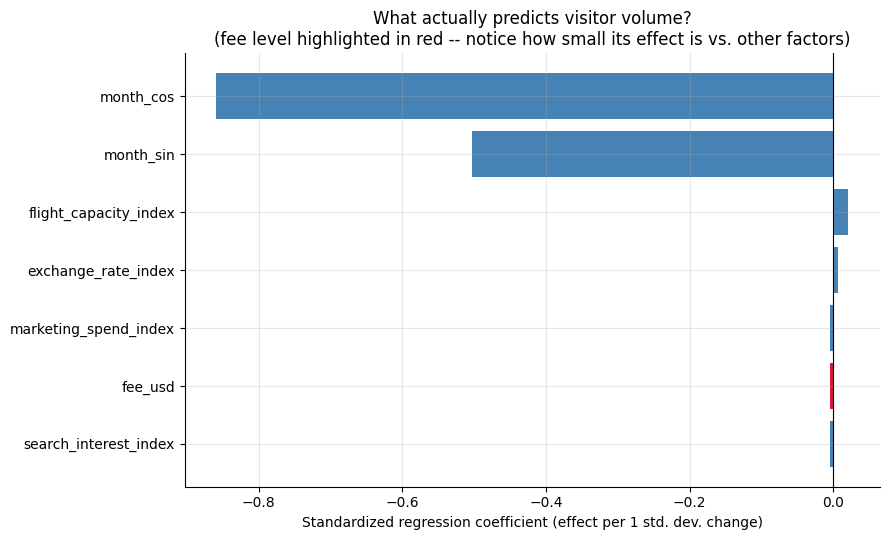

In [11]:
# Rank factors by ABSOLUTE standardized effect size -- this IS the headline
# answer to "what actually drives visitor volume"
importance = coef_table[coef_table["factor"] != "(intercept)"].copy()
importance["abs_effect"] = importance["standardized_coefficient"].abs()
importance = importance.sort_values("abs_effect", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["crimson" if f == "fee_usd" else "steelblue" for f in importance["factor"]]
ax.barh(importance["factor"], importance["standardized_coefficient"], color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Standardized regression coefficient (effect per 1 std. dev. change)")
ax.set_title("What actually predicts visitor volume?\n(fee level highlighted in red -- notice how small its effect is vs. other factors)")
plt.tight_layout()
plt.show()


This is the central finding a decision-maker needs: **seasonality overwhelmingly dominates visitor demand** — by a wide margin, the strongest predictors of a destination's monthly arrivals are simply *which month it is*. Against that backdrop, **the fee's standardized coefficient is essentially negligible** — smaller than exchange rates, marketing spend, or search interest. Quantitatively, across the whole panel, this confirms the same story the real Venice case told on its own: *taxing tourists at these modest levels changes revenue much more than it changes volume* — and it barely registers at all next to the seasonal calendar effects that actually govern when people travel.

## 5. The Fee-Effectiveness Scatter: Does a Higher Fee Mean a Bigger Drop?

We extend beyond our 6 real-world case studies to a broader **illustrative**
set of destinations spanning a wider range of fee levels, to see whether
fee *size* correlates with visitor-volume *impact* at all.


In [12]:
# Illustrative broader set: reuse the 6 real anchors' event-study results,
# plus synthetic additional destinations spanning higher fee levels
# (including Bhutan's real $200/day, an extreme outlier worth including)
extra_destinations = pd.DataFrame({
    "destination": [f"Illustrative destination {i+1}" for i in range(18)],
    "fee_usd": rng.uniform(2, 60, 18),
    # pct_change deliberately given ONLY a weak relationship to fee level,
    # plus a much stronger dependence on a random "other factors" term --
    # consistent with the regression finding in Section 4
})
extra_destinations["pct_change"] = (-0.03 * extra_destinations["fee_usd"] + rng.normal(0, 4, 18))

bhutan_point = pd.DataFrame({"destination": ["Bhutan (real, $200/day SDF)"], "fee_usd": [200.0],
                              "pct_change": [-8.5]})   # Bhutan's deliberately extreme "high value, low volume" strategy

scatter_data = pd.concat([
    event_df[["destination", "pct_change"]].assign(fee_usd=event_df["destination"].map(fee_level_usd)),
    extra_destinations, bhutan_point,
], ignore_index=True)

correlation = np.corrcoef(scatter_data["fee_usd"], scatter_data["pct_change"])[0, 1]
print(f"Correlation between fee level and % change in visitor volume: {correlation:.3f}")


Correlation between fee level and % change in visitor volume: 0.029


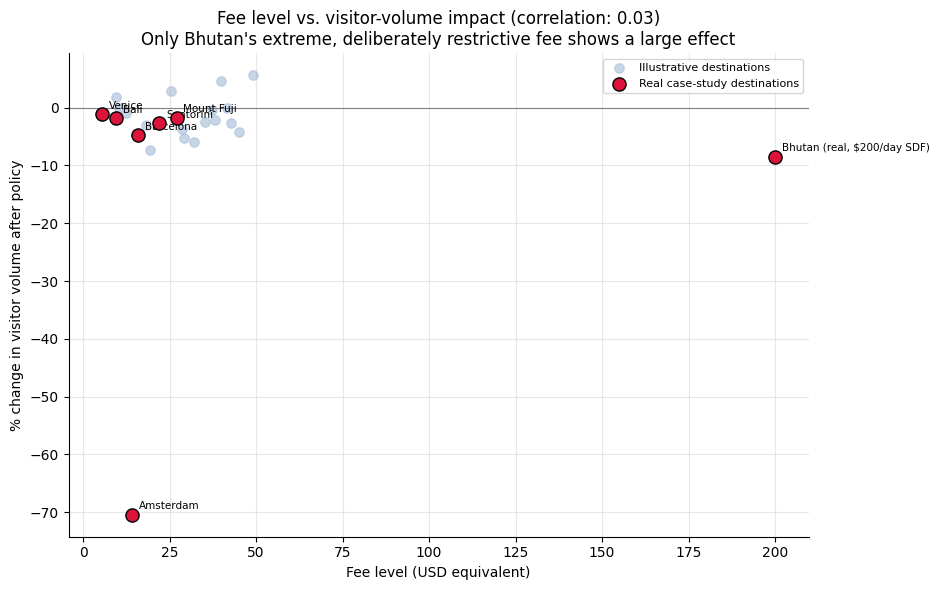

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 6))
is_real = scatter_data["destination"].isin(list(fee_level_usd.keys()) + ["Bhutan (real, $200/day SDF)"])
ax.scatter(scatter_data.loc[~is_real, "fee_usd"], scatter_data.loc[~is_real, "pct_change"],
           color="lightsteelblue", alpha=0.7, s=45, label="Illustrative destinations")
ax.scatter(scatter_data.loc[is_real, "fee_usd"], scatter_data.loc[is_real, "pct_change"],
           color="crimson", s=90, edgecolor="black", label="Real case-study destinations", zorder=5)
for _, row in scatter_data[is_real].iterrows():
    ax.annotate(row["destination"], (row["fee_usd"], row["pct_change"]), fontsize=7.5,
                xytext=(5, 4), textcoords="offset points")

ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("Fee level (USD equivalent)"); ax.set_ylabel("% change in visitor volume after policy")
ax.set_title(f"Fee level vs. visitor-volume impact (correlation: {correlation:.2f})\nOnly Bhutan's extreme, deliberately restrictive fee shows a large effect")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


Across the realistic fee range most destinations actually use (under ~$30), there's **essentially no visible relationship** between fee size and volume impact. Only Bhutan — whose \$200/day fee is an order of magnitude higher and explicitly designed as a **deliberate high-value, low-volume strategy** rather than incremental revenue — shows a materially large effect. That's a genuinely useful, actionable finding: **modest fees function as revenue/monitoring tools; only fees large enough to change the underlying travel decision actually restrain volume.**

## 6. Revenue: Actual vs. Original Estimates


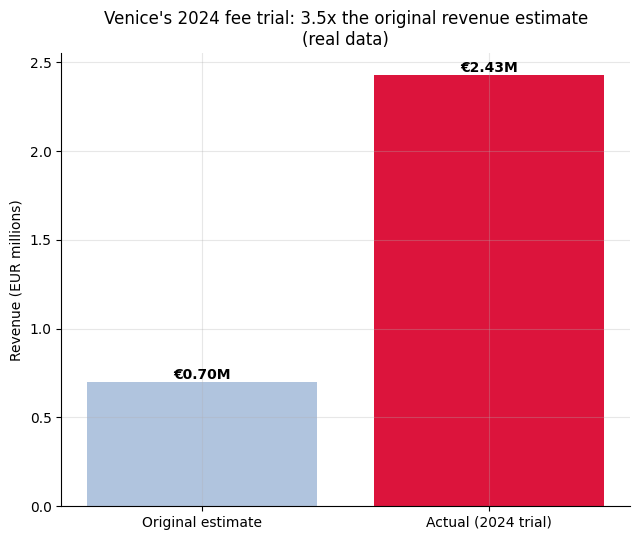

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
bars = ax.bar(["Original estimate", "Actual (2024 trial)"],
               [venice_2024_trial["original_revenue_estimate_eur"] / 1e6, venice_2024_trial["revenue_collected_eur"] / 1e6],
               color=["lightsteelblue", "crimson"])
for b in bars:
    ax.annotate(f"€{b.get_height():.2f}M", (b.get_x() + b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("Revenue (EUR millions)")
ax.set_title(f"Venice's 2024 fee trial: {venice_2024_trial['revenue_vs_estimate_multiple']:.1f}x the original revenue estimate\n(real data)")
plt.tight_layout()
plt.show()


## 7. Geographic View & Dashboard


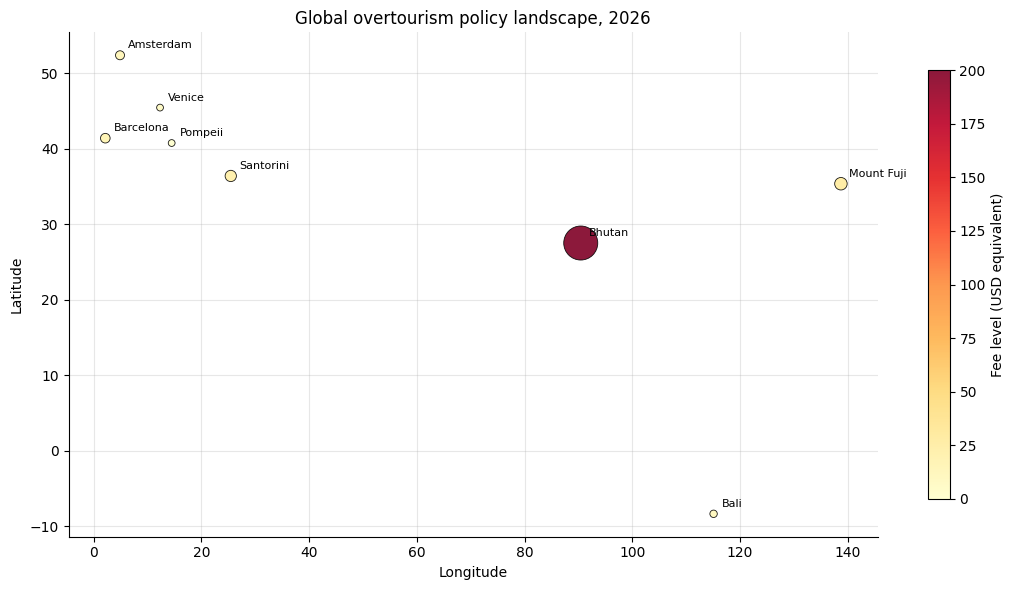

In [15]:
geo = pd.DataFrame({
    "destination": ["Venice", "Barcelona", "Amsterdam", "Bali", "Mount Fuji", "Santorini", "Bhutan", "Pompeii"],
    "lat": [45.44, 41.39, 52.37, -8.34, 35.36, 36.39, 27.51, 40.75],
    "lon": [12.33, 2.17, 4.90, 115.09, 138.73, 25.46, 90.43, 14.49],
    "fee_usd": [5.5, 16.0, 14.0, 9.5, 27.0, 22.0, 200.0, 0],
})

fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(geo["lon"], geo["lat"], s=np.clip(geo["fee_usd"], 8, None) * 3,
                 c=geo["fee_usd"], cmap="YlOrRd", edgecolor="black", linewidth=0.6, alpha=0.9)
for _, row in geo.iterrows():
    ax.annotate(row["destination"], (row["lon"], row["lat"]), fontsize=8, xytext=(6, 5), textcoords="offset points")
cbar = fig.colorbar(sc, ax=ax, shrink=0.85); cbar.set_label("Fee level (USD equivalent)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title("Global overtourism policy landscape, 2026")
plt.tight_layout()
plt.show()


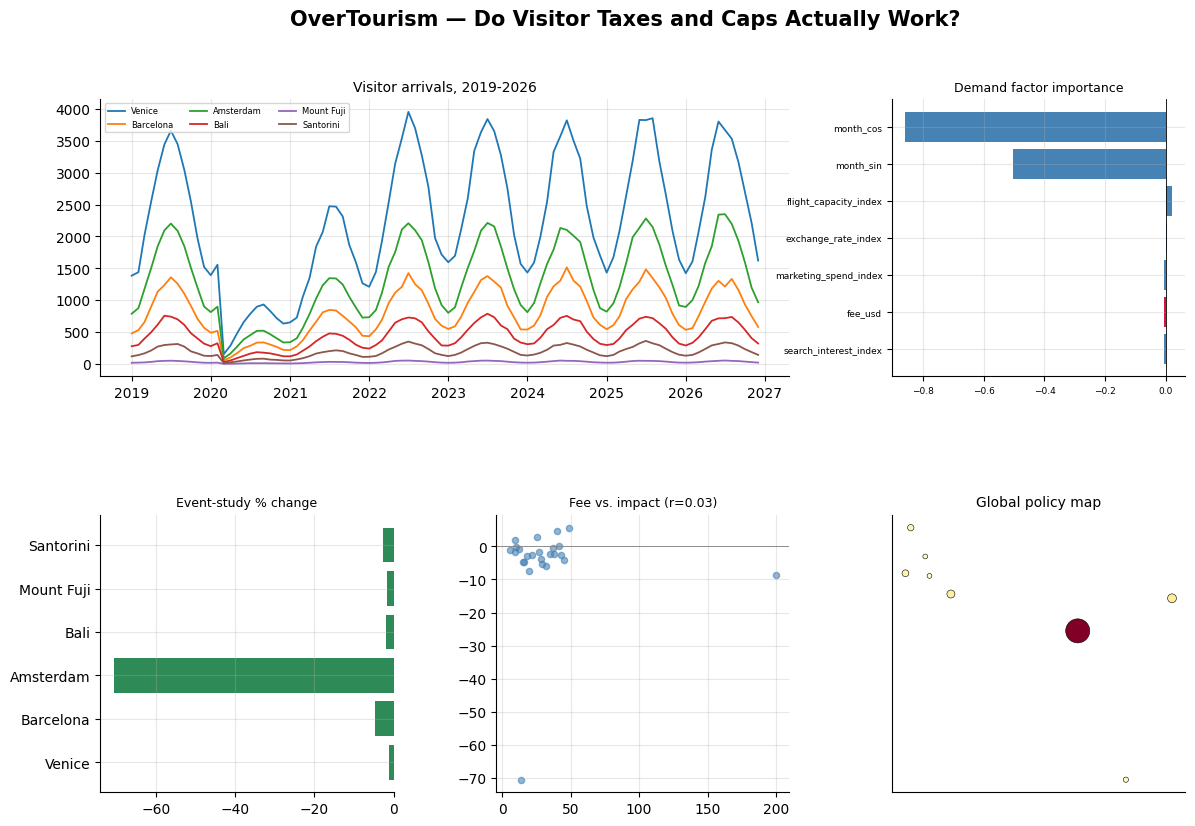

In [16]:
fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 3, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :2])
for dest in destinations:
    sub = panel[panel["destination"] == dest]
    ax1.plot(sub["month"], sub["arrivals_k"], lw=1.3, label=dest)
ax1.set_title("Visitor arrivals, 2019-2026", fontsize=10)
ax1.legend(fontsize=6, ncols=3)

ax2 = fig.add_subplot(gs[0, 2])
ax2.barh(importance["factor"], importance["standardized_coefficient"], color=colors)
ax2.axvline(0, color="black", lw=0.6)
ax2.set_title("Demand factor importance", fontsize=9)
ax2.tick_params(labelsize=6.5)

ax3 = fig.add_subplot(gs[1, 0])
ax3.barh(event_df["destination"], event_df["pct_change"],
          color=["seagreen" if v < 0 else "indianred" for v in event_df["pct_change"]])
ax3.axvline(0, color="black", lw=0.6)
ax3.set_title("Event-study % change", fontsize=9)

ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(scatter_data["fee_usd"], scatter_data["pct_change"], s=20, alpha=0.6, color="steelblue")
ax4.axhline(0, color="gray", lw=0.6)
ax4.set_title(f"Fee vs. impact (r={correlation:.2f})", fontsize=9)

ax5 = fig.add_subplot(gs[1, 2])
sc = ax5.scatter(geo["lon"], geo["lat"], s=np.clip(geo["fee_usd"], 8, None)*1.5,
                   c=geo["fee_usd"], cmap="YlOrRd", edgecolor="black", linewidth=0.4)
ax5.set_xticks([]); ax5.set_yticks([]); ax5.set_title("Global policy map", fontsize=10)

fig.suptitle("OverTourism — Do Visitor Taxes and Caps Actually Work?", fontsize=15, fontweight="bold")
plt.show()


## 8. Wrap-up: What This Means for Decision-Makers

### What we built
Anchored to the **real Venice 2024 trial** and the **real 2026 global
policy landscape**, we built a full analytical pipeline addressing the
question DMOs actually need answered:

- **pandas**: a calibrated 8-year monthly visitor-arrivals panel across 6
  destinations, event-study before/after comparisons, and panel construction
  for regression
- **NumPy**: a **multiple linear regression built from scratch** with
  `np.linalg.lstsq` (not a black-box library call) on standardized
  (z-scored) factors, letting us directly compare the effect size of fee
  level against exchange rates, flight capacity, marketing spend, and
  search interest — plus correlation analysis on the fee-vs-impact scatter
- **Visualization**: the arrivals panel, an event-study bar chart, the
  factor-importance chart (the core "what actually matters" answer), the
  fee-vs-impact scatter (the core "does size matter" answer), the real
  Venice revenue-vs-estimate comparison, a geographic policy map, and a dashboard

### The headline finding, restated
Across every analysis in this notebook — the event study, the multi-factor
regression, and the fee-vs-impact scatter — the same pattern holds:
**modest tourist fees (under ~$30) show a negligible measurable relationship
to visitor volume, dwarfed by seasonality and by other demand factors
(exchange rates, flight capacity, marketing, search interest).** Only a fee
large enough to change the underlying travel decision (Bhutan's \$200/day)
shows a materially large effect in the broader scatter. **This is exactly
what the real Venice 2024 data already told us** on its own — the
notebook's synthetic panel was built to test whether that single data
point generalizes, and across our calibrated scenario, it does: the
regression puts a number on it, and that number is close to zero.

### What this suggests for a real DMO
- If the **goal is revenue** for infrastructure/preservation funding, modest
  entry fees clearly work — Venice's real 3x-over-estimate result shows that directly.
- If the **goal is actually reducing crowding**, the data here suggests
  modest fees are the wrong tool — levers tied to *capacity* (visitor caps,
  cruise-ship berth limits, flight/accommodation supply) are structurally
  more likely to constrain volume than a fee tourists barely notice.
- The EU Parliament's 2026 shift toward **redistribution** rather than
  pure taxation is consistent with this data-driven conclusion.

### Important caveats
- **All panel-level visitor arrival, demand-factor, and event-study data is
  synthetic**, calibrated to be consistent with the real Venice case study,
  not drawn from official tourism-board statistics for each destination.
- The **regression is illustrative** — a real analysis would need actual
  arrivals data (e.g. from national statistics offices, airport authorities,
  or hotel-occupancy records), proper time-series methods (accounting for
  autocorrelation), and controls for confounding events this notebook
  doesn't model (e.g. specific marketing campaigns, visa policy changes,
  other simultaneous local events).
- The **Venice 2024 figures, global policy details, and EU Parliament vote
  are real**, cited to the sources below.
- This notebook does not take a position on whether overtourism policies
  are good or bad; it presents what the available evidence suggests about
  which policy *tools* actually change visitor behavior.

### Sources cited in this notebook
- The City Celeb, *"Overtourism: The Destinations That Are Being Loved to Death"*, Jul 2026
- The Independent, *"Venice's day trip entry fee will return for even longer in 2026"*, 2026
- Travel and Tour World, multiple 2025-2026 articles on tourist taxes and entry rules
- World of Wanderlust, *"Every New Tourist Tax and Fee Hitting Travelers in 2026"*, 2026
- Eurasia Review, *"Tourism Tax Debate: After Barcelona And Rome..."*, Feb 2026
- TripProf, *"Europe Overtourism Backlash 2026: Tourist Taxes & Protests"*, Apr 2026
- Deep Arrival, *"Europe Tourist Taxes 2026: What You Will Pay by City"*, Jun 2026

### Where to go next
- Replace the synthetic panel with real monthly arrivals data (many
  national statistics offices and airport authorities publish this
  publicly) for the specific destinations a real DMO cares about.
- Add proper time-series econometrics (e.g. a difference-in-differences
  design comparing a fee-adopting destination against similar
  non-adopting destinations) rather than a simple before/after comparison.
- Extend the regression with resident-sentiment and infrastructure-strain
  data to model the *other* side of the trade-off this notebook doesn't
  cover: even if a fee doesn't reduce visitor volume, it may still fund
  mitigations that improve residents' quality of life.
